In [1]:
import torch, torchvision
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

import numpy as np
import os, json, random, itertools
import cv2 as cv
import matplotlib.pyplot as plt

from detectron2.structures import BoxMode
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor, DefaultTrainer
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0  204k    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  204k  100  204k    0     0   137k      0  0:00:01  0:00:01 --:--:--  138k


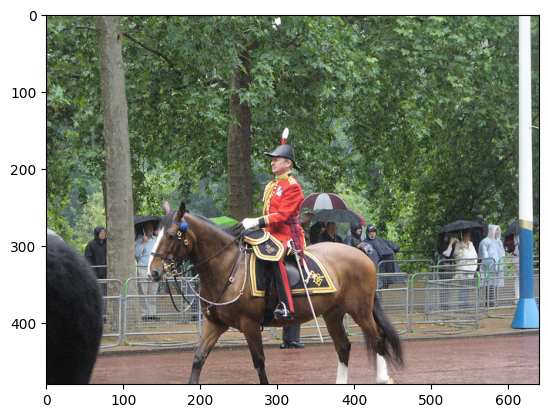

In [2]:
!curl -o input.jpg http://images.cocodataset.org/val2017/000000439715.jpg

img = cv.imread("input.jpg")
plt.imshow(img[..., ::-1])
plt.show()

In [3]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_1x.yaml"))
cfg.MODEL.WEIGHTS = "./models/mask-rcnn-r-50-fpn_coco/model_final_a54504.pkl"
# Path to the downloaded weights
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Set the threshold for predictions
cfg.MODEL.DEVICE = "cpu"

In [4]:
predictor = DefaultPredictor(cfg)

[04/04 10:20:37 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./models/mask-rcnn-r-50-fpn_coco/model_final_a54504.pkl ...


In [5]:
outputs = predictor(img)

D:\Py-Projects\test\Computer-Vision\.venv\lib\site-packages\torch\functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [6]:
print(outputs["instances"].pred_classes)
print(outputs["instances"].pred_boxes)

tensor([17,  0,  0,  0,  0,  0,  0,  0, 25,  0, 25, 25, 25,  0])
Boxes(tensor([[129.4912, 242.0283, 472.6100, 480.0000],
        [247.3995, 157.0880, 337.9084, 418.3694],
        [113.7692, 270.7695, 148.3774, 393.9277],
        [560.1945, 271.4650, 595.2225, 376.9260],
        [ 49.3435, 273.3748,  80.4923, 348.4358],
        [  0.0000, 277.1792,  77.4022, 477.7699],
        [386.4144, 271.4767, 414.2008, 306.0018],
        [515.2707, 279.4132, 561.6492, 382.2124],
        [328.3157, 251.6637, 414.4686, 276.6138],
        [346.0595, 268.4080, 386.6658, 299.2833],
        [508.5651, 265.5274, 572.0912, 292.1199],
        [330.2429, 230.7285, 393.0111, 256.7546],
        [328.1802, 232.2943, 404.8302, 285.5402],
        [407.3222, 273.2192, 459.5058, 351.0341]]))


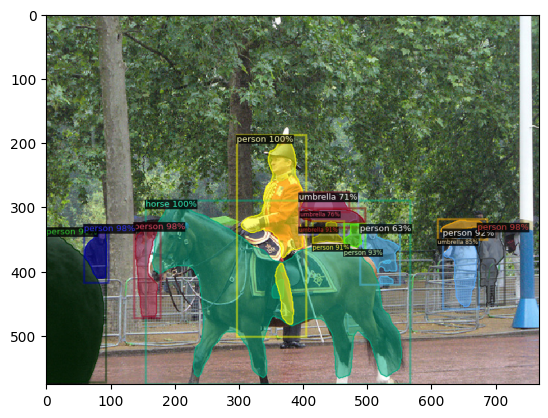

In [7]:
v = Visualizer(img[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
plt.imshow(out.get_image())
plt.show()

In [8]:
def get_balloon_dicts(img_dir):
    json_file = os.path.join(img_dir, "via_region_data.json")
    with open(json_file) as f:
        imgs_anns = json.load(f)

    dataset_dicts = []
    for _, v in imgs_anns.items():
        record = {}

        filename = os.path.join(img_dir, v["filename"])
        height, width = cv.imread(filename).shape[:2]

        record["file_name"] = filename
        record["height"] = height
        record["width"] = width

        annos = v["regions"]
        objs = []
        for _, anno in annos.items():
            assert not anno["region_attributes"]
            anno = anno["shape_attributes"]
            px = anno["all_points_x"]
            py = anno["all_points_y"]
            poly = [(x + 0.5, y + 0.5) for x, y in zip(px, py)]
            poly = list(itertools.chain.from_iterable(poly))

            obj = {
                "bbox": [np.min(px), np.min(py), np.max(px), np.max(py)],
                "bbox_mode": BoxMode.XYWH_ABS,
                "segmentation": [poly],
                "category_id": 0,
                "iscrowd": 0
            }
            objs.append(obj)

        record["annotations"] = objs
        dataset_dicts.append(record)

    return dataset_dicts

In [9]:
for d in ["train", "val"]:
    DatasetCatalog.register("./datasets/balloons/" + d, lambda d = d: get_balloon_dicts("./datasets/balloons/" + d))
    MetadataCatalog.get("./datasets/balloons/" + d).set(thing_classes=["balloon"])
balloon_metadata = MetadataCatalog.get("./datasets/balloons/train")

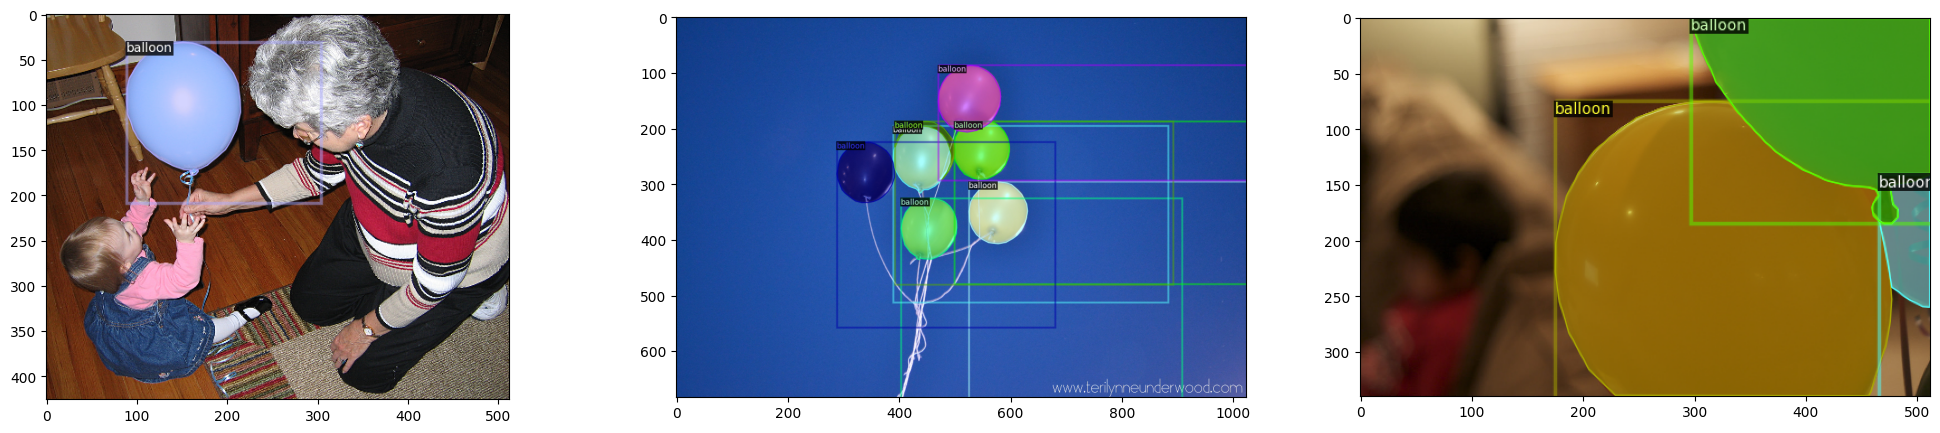

In [10]:
dataset_dicts = get_balloon_dicts("./datasets/balloons/train")
plt.figure(figsize=(25, 5))
for i, d in enumerate(random.sample(dataset_dicts, 3)):
    img = cv.imread(d["file_name"])
    visualizer = Visualizer(img[..., ::-1], metadata = balloon_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)
    plt.subplot(1, 3, i + 1)
    plt.imshow(vis.get_image())

In [11]:
cfg.DATASETS.TRAIN = ("./datasets/balloons/train",)
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 2
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 300
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1

In [12]:
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[04/03 21:07:32 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (2, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (2,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (4, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (4,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (1, 256, 1, 1) in

[04/03 21:07:33 d2.engine.train_loop]: Starting training from iteration 0
[04/03 21:10:08 d2.utils.events]:  eta: 0:33:49  iter: 19  total_loss: 2.078  loss_cls: 0.6403  loss_box_reg: 0.5435  loss_mask: 0.6861  loss_rpn_cls: 0.09012  loss_rpn_loc: 0.02914    time: 7.4964  last_time: 8.7119  data_time: 0.1368  last_data_time: 0.0020   lr: 1.6068e-05  
[04/03 21:12:48 d2.utils.events]:  eta: 0:33:43  iter: 39  total_loss: 1.922  loss_cls: 0.5591  loss_box_reg: 0.5687  loss_mask: 0.6466  loss_rpn_cls: 0.06845  loss_rpn_loc: 0.02831    time: 7.6474  last_time: 8.8245  data_time: 0.0019  last_data_time: 0.0018   lr: 3.2718e-05  
[04/03 21:15:25 d2.utils.events]:  eta: 0:31:14  iter: 59  total_loss: 1.781  loss_cls: 0.4893  loss_box_reg: 0.5339  loss_mask: 0.5693  loss_rpn_cls: 0.08239  loss_rpn_loc: 0.03724    time: 7.7198  last_time: 8.0171  data_time: 0.0020  last_data_time: 0.0021   lr: 4.9367e-05  
[04/03 21:17:56 d2.utils.events]:  eta: 0:28:51  iter: 79  total_loss: 1.608  loss_cls: 0

In [17]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.9
cfg.DATASETS.TEST = ("balloon_val",)
predictor = DefaultPredictor(cfg)

[04/03 23:14:57 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output\model_final.pth ...


In [58]:
cfg.MODEL.WEIGHTS = "./models/mask-rcnn-r-50-fpn_coco/output/model_final.pth"  # Path to the trained model
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.9  # Set threshold for predictions
cfg.DATASETS.TEST = ("balloon_val",)
cfg.MODEL.DEVICE = "cpu"  # Use "cuda" for GPU or "cpu" for CPU

pre = DefaultPredictor(cfg)

[04/04 11:08:20 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./models/mask-rcnn-r-50-fpn_coco/output/model_final.pth ...


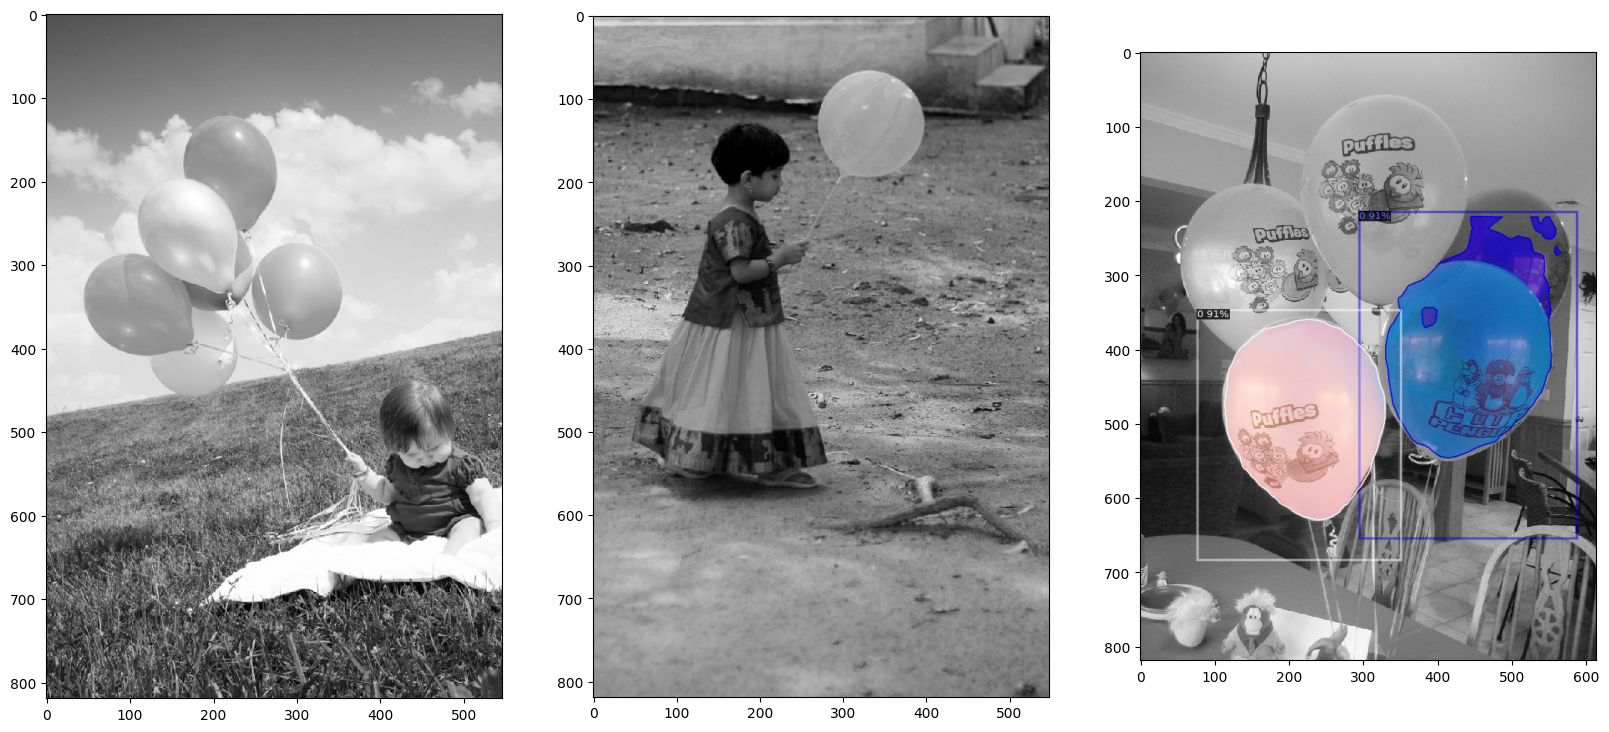

In [59]:
plt.figure(figsize=(20, 10))
from detectron2.utils.visualizer import ColorMode
dataset_dicts = get_balloon_dicts("./datasets/balloons/val")
for i, d in enumerate(random.sample(dataset_dicts, 3)):
    im = cv.imread(d["file_name"])
    outputs = pre(im)
    v = Visualizer(im[:, :, ::-1],
                   metadata=MetadataCatalog.get("balloon_val"),
                   scale=0.8,
                   instance_mode=ColorMode.IMAGE_BW   # remove the colors of unsegmented pixels
    )
    v = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    plt.subplot(1, 3, i + 1)
    plt.imshow(v.get_image()[:, :, ::-1])